# Small-Scale Classification Benchmark with Scikit-learn and Spark


This notebook is shared as a portfolio project to demonstrate binary classification, categorical preprocessing, Random Forest modeling, and comparison between Scikit-learn and Spark-based workflows.

The notebook focuses on the Mushroom dataset as a small categorical dataset and compares baseline and Spark-based classification approaches using runtime and classification metrics.


## Scikit-learn Baseline

In [3]:
import pandas as pd
from pathlib import Path

column_names = [
    "class",  # e = edible, p = poisonous
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]
file_path = Path("../data/agaricus-lepiota.data")
base_data = pd.read_csv(file_path, header=None, names=column_names)

## Dataset

The Mushroom dataset is a categorical binary classification dataset. Each row describes physical mushroom characteristics such as cap shape, cap color, odor, gill size, population, and habitat.

The target variable is whether a mushroom is edible or poisonous.

Further explanation of the original dataset categories can be found in the UCI Mushroom dataset documentation.

In [32]:

print(f'Train data:\n{base_data.head()}')
print(f'{base_data.info()}')
print(f'Missing values in Train data:\n{base_data.isnull().sum()}\n->This dataset has no missing values.')

Train data:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w

## Baseline Preprocessing

The dataset contains categorical values, so the baseline workflow converts them into numeric features using `OrdinalEncoder`.

The target class is mapped into binary labels:

- `0`: edible
- `1`: poisonous

The dataset is then split into training and test sets using a 70/30 split.

In [53]:
# Extract target feature from dataset
X = base_data.drop("class", axis=1)

# Map target labels into binary values
y = base_data["class"] = base_data["class"].map({'e': 0, 'p': 1})  # edible=0, poisonous=1


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert categorical feature values into numbers
# using ordinal encoder
encoder = OrdinalEncoder()

# Apply Encoder to each column
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

## Train the Scikit-learn Random Forest Model

In [56]:
from sklearn.ensemble import RandomForestClassifier
import time

start_time = time.time()

# Construct classifier
clf = RandomForestClassifier(criterion="gini", random_state=42,  n_estimators=3, max_depth=4 )

# Fit your classifier here
clf = clf.fit(X_train_encoded, y_train)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.4f} seconds")

depths = [estimator.get_depth() for estimator in clf.estimators_]
print(f"Maximum depth among all trees: {max(depths)}")
print(f"Minimum depth among all trees: {min(depths)}")
print(f"Average depth: {sum(depths)/len(depths):.2f}")


Training time: 0.0229 seconds
Maximum depth among all trees: 4
Minimum depth among all trees: 4
Average depth: 4.00


                     Feature  Importance
4                       odor    0.301610
18                 ring-type    0.233871
11  stalk-surface-above-ring    0.093969
6               gill-spacing    0.086461
20                population    0.061352
10                stalk-root    0.054917
17               ring-number    0.041445
8                 gill-color    0.033831
19         spore-print-color    0.029176
14    stalk-color-below-ring    0.026990
12  stalk-surface-below-ring    0.022653
3                    bruises    0.007914
2                  cap-color    0.003507
16                veil-color    0.002305
15                 veil-type    0.000000
0                  cap-shape    0.000000
13    stalk-color-above-ring    0.000000
1                cap-surface    0.000000
9                stalk-shape    0.000000
7                  gill-size    0.000000
5            gill-attachment    0.000000
21                   habitat    0.000000


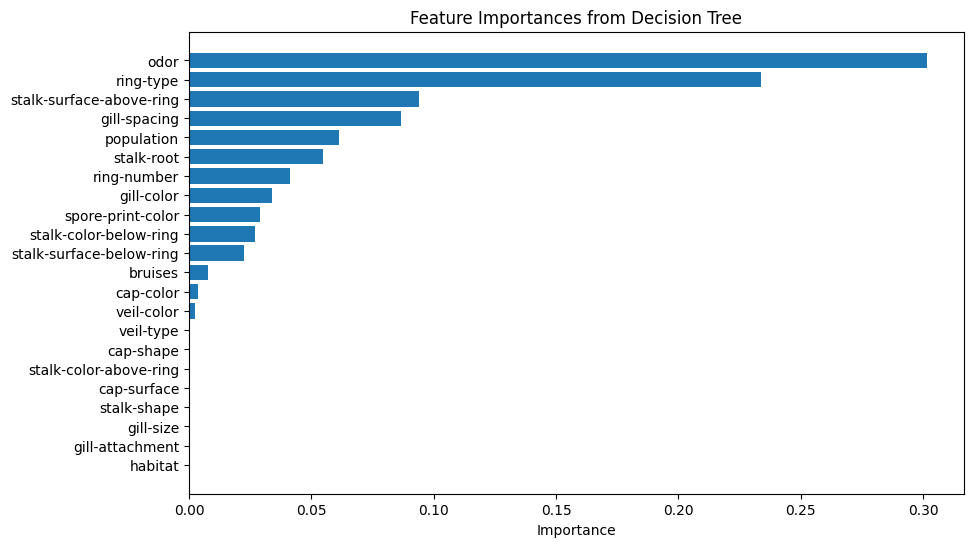

In [57]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
features = X.columns

# Combine into a DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

#plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Decision Tree')
plt.gca().invert_yaxis()
plt.show()


## Evaluate the Scikit-learn Baseline

In [58]:
start_time = time.time()

y_pred = clf.predict(X_test_encoded)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Evaluation time: {elapsed_time:.4f} seconds")

Evaluation time: 0.0020 seconds


### Baseline Classification Metrics

In [59]:
from sklearn.metrics import classification_report, confusion_matrix
print('confusion_matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nclassification_report:')
print(classification_report(y_test, y_pred))

confusion_matrix:
[[1249    8]
 [  54 1127]]

classification_report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1257
           1       0.99      0.95      0.97      1181

    accuracy                           0.97      2438
   macro avg       0.98      0.97      0.97      2438
weighted avg       0.98      0.97      0.97      2438



## Spark-Based Parallelization Workflow

In [79]:
# Optional PySpark environment configuration.
# Uncomment and adapt this section only if PySpark needs a specific Python environment.

# import os
# python_path = r"path_to_python_environment"
# os.environ["PYSPARK_PYTHON"] = python_path
# os.environ["PYSPARK_DRIVER_PYTHON"] = python_path


In [80]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Mushroom Small Dataset Spark Benchmark") \
    .master("local[4]") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

column_names = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat"
]

parallel_data = spark.read.csv(file_path,
    header=False,
    inferSchema=True
).toDF(*column_names)

print(parallel_data)


DataFrame[class: string, cap-shape: string, cap-surface: string, cap-color: string, bruises: string, odor: string, gill-attachment: string, gill-spacing: string, gill-size: string, gill-color: string, stalk-shape: string, stalk-root: string, stalk-surface-above-ring: string, stalk-surface-below-ring: string, stalk-color-above-ring: string, stalk-color-below-ring: string, veil-type: string, veil-color: string, ring-number: string, ring-type: string, spore-print-color: string, population: string, habitat: string]


## About the Dataset


In [23]:
parallel_data.show(5)
parallel_data.printSchema()


+-----+---------+-----------+---------+-------+----+---------------+------------+---------+----------+-----------+----------+------------------------+------------------------+----------------------+----------------------+---------+----------+-----------+---------+-----------------+----------+-------+
|class|cap-shape|cap-surface|cap-color|bruises|odor|gill-attachment|gill-spacing|gill-size|gill-color|stalk-shape|stalk-root|stalk-surface-above-ring|stalk-surface-below-ring|stalk-color-above-ring|stalk-color-below-ring|veil-type|veil-color|ring-number|ring-type|spore-print-color|population|habitat|
+-----+---------+-----------+---------+-------+----+---------------+------------+---------+----------+-----------+----------+------------------------+------------------------+----------------------+----------------------+---------+----------+-----------+---------+-----------------+----------+-------+
|    p|        x|          s|        n|      t|   p|              f|           c|        n|   

## Spark Preprocessing

The Spark workflow uses `StringIndexer` to convert categorical string columns into indexed numeric features. The indexed features are then combined into a single feature vector using `VectorAssembler`.

In [81]:
# Repartition the Spark DataFrame for the benchmark
parallel_data = parallel_data.repartition(8)

In [82]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Assume 'df' is your Spark DataFrame and column_names includes all columns
feature_cols = column_names[1:]  # exclude 'class'
label_col = column_names[0]      # usually 'class'

# 1. Index the label column ('class' → 'label')
label_indexer = StringIndexer(inputCol=label_col, outputCol="label")

# 2. Index all categorical feature columns
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep")
    for col in feature_cols
]

# 3. Assemble all indexed features into one feature vector
assembler = VectorAssembler(
    inputCols=[col + "_idx" for col in feature_cols],
    outputCol="features"
)

### Train and Test the Spark Random Forest Model

In [83]:
from time import time
def with_benchmark(phrase, action):
    start = time()
    result = action()
    end = time()
    print('{} took {} seconds'.format(phrase, round(end - start, 2)))
    return result

In [84]:

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 3. Define the classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=3, maxDepth=4, seed=42)

# 4. Build the pipeline
pipeline = Pipeline(stages=[label_indexer] + indexers + [assembler, rf])

# 5. Split the data
train_parallel_data, test_parallel_data = parallel_data.randomSplit([0.7, 0.3], seed=42)

# 6. Train the model
model = with_benchmark('Training', lambda: pipeline.fit(train_parallel_data))


# 7. Make predictions
predictions = model.transform(test_parallel_data)




Training took 9.09 seconds


### Classification Metrics

In [85]:
accuracy = with_benchmark(
    'Evaluation',
    lambda: MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
)

print('Accuracy is ' + str(accuracy))


Evaluation took 0.6 seconds
Accuracy is 0.988698200083717


In [86]:
from pyspark.mllib.evaluation import MulticlassMetrics

prediction_and_labels = predictions.select("prediction", "label")

# Convert the DataFrame to an RDD of tuples
prediction_rdd = prediction_and_labels.rdd

# Compute metrics using the RDD (this will be used for confusion matrix)
metrics = MulticlassMetrics(prediction_rdd)

# Get the confusion matrix and convert it to an array
confusion_matrix = metrics.confusionMatrix().toArray()

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[1.270e+03 1.000e+00]
 [2.600e+01 1.092e+03]]


In [77]:
# For label 0
precision_0 = metrics.precision(0.0)
recall_0 = metrics.recall(0.0)
f1_score_0 = metrics.fMeasure(0.0)

# For label 1
precision_1 = metrics.precision(1.0)
recall_1 = metrics.recall(1.0)
f1_score_1 = metrics.fMeasure(1.0)

print(f"Class 0 - Precision: {precision_0}, Recall: {recall_0}, F1 Score: {f1_score_0}")
print(f"Class 1 - Precision: {precision_1}, Recall: {recall_1}, F1 Score: {f1_score_1}")


weighted_precision = metrics.weightedPrecision
weighted_recall = metrics.weightedRecall
weighted_f1 = metrics.weightedFMeasure()

print(f"Weighted Precision: {weighted_precision}")
print(f"Weighted Recall: {weighted_recall}")
print(f"Weighted F1 Score: {weighted_f1}")

Class 0 - Precision: 0.9799382716049383, Recall: 0.999213217938631, F1 Score: 0.9894818854694196
Class 1 - Precision: 0.9990850869167429, Recall: 0.9767441860465116, F1 Score: 0.9877883310719131
Weighted Precision: 0.9888985644130579
Weighted Recall: 0.988698200083717
Weighted F1 Score: 0.988689338874019


In [78]:
spark.stop()

## Final Interpretation

The results compare a fast Scikit-learn baseline with a Spark-based workflow on a small categorical dataset.

For this small dataset, the Scikit-learn baseline runs faster because Spark introduces additional overhead. The Spark workflow still achieves strong classification performance, but the runtime comparison shows that Spark is not always the best choice for small-scale data.

This notebook is intended as a focused portfolio version of the small-dataset classification and Spark benchmarking workflow.
